In [1]:
import pandas as pd   
import numpy as np

In [8]:
df = pd.read_csv('climate_change.csv')
df.head(5)

,Year,Month,MEI,CO2,CH4,N2O,CFC-11,CFC-12,TSI,Aerosols,Temp
0,1983,5,2.556,345.96,1638.59,303.677,191.324,350.113,1366.1024,0.0863,0.109
1,1983,6,2.167,345.52,1633.71,303.746,192.057,351.848,1366.1208,0.0794,0.118
2,1983,7,1.741,344.15,1633.22,303.795,192.818,353.725,1366.2850,0.0731,0.137
3,1983,8,1.130,342.25,1631.35,303.839,193.602,355.633,1366.4202,0.0673,0.176
4,1983,9,0.428,340.17,1648.40,303.901,194.392,357.465,1366.2335,0.0619,0.149


In [21]:
print(df.shape)
df.dropna(inplace=True)
print(df.shape)

(308, 11)
(308, 11)


In [22]:
a = df['Year'].values
a

array([1983, 1983, 1983, 1983, 1983, 1983, 1983, 1983, 1984, 1984, 1984,
       1984, 1984, 1984, 1984, 1984, 1984, 1984, 1984, 1984, 1985, 1985,
       1985, 1985, 1985, 1985, 1985, 1985, 1985, 1985, 1985, 1985, 1986,
       1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986, 1986,
       1987, 1987, 1987, 1987, 1987, 1987, 1987, 1987, 1987, 1987, 1987,
       1987, 1988, 1988, 1988, 1988, 1988, 1988, 1988, 1988, 1988, 1988,
       1988, 1988, 1989, 1989, 1989, 1989, 1989, 1989, 1989, 1989, 1989,
       1989, 1989, 1989, 1990, 1990, 1990, 1990, 1990, 1990, 1990, 1990,
       1990, 1990, 1990, 1990, 1991, 1991, 1991, 1991, 1991, 1991, 1991,
       1991, 1991, 1991, 1991, 1991, 1992, 1992, 1992, 1992, 1992, 1992,
       1992, 1992, 1992, 1992, 1992, 1992, 1993, 1993, 1993, 1993, 1993,
       1993, 1993, 1993, 1993, 1993, 1993, 1993, 1994, 1994, 1994, 1994,
       1994, 1994, 1994, 1994, 1994, 1994, 1994, 1994, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 19

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_names = df.columns.drop(['Temp','Year','Month'])

df_train = df[df['Year'] < 2006]
df_test = df[df['Year'] >= 2006]
scaler = StandardScaler().fit(df_train[feature_names])
X_train = scaler.transform(df_train[feature_names])
y_train = df_train['Temp']

X_test = scaler.transform(df_test[feature_names])
y_test = df_test['Temp']

# X_train.head(5)


Accuracy on test set:  99.90503737414512
Accuracy on training set:  99.9079292349895
Accuracy on test set:  99.91578116219488
Accuracy on training set:  99.90826879881394


<Axes: >

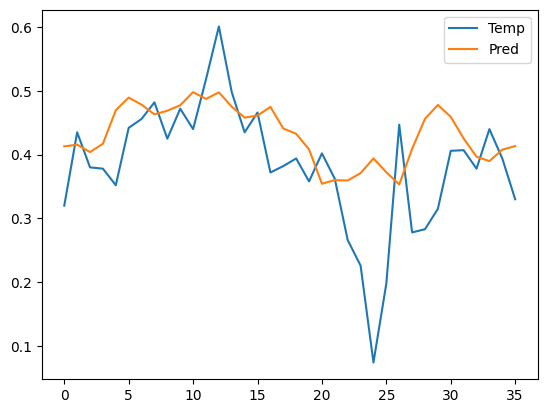

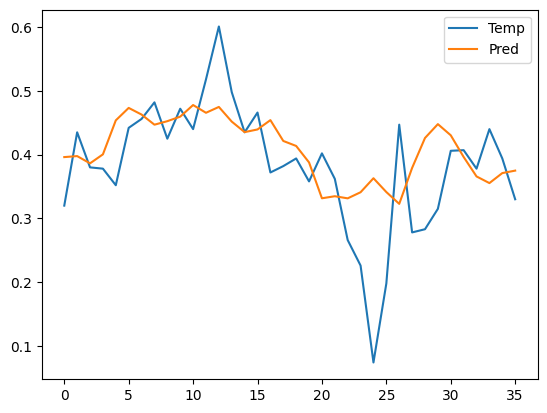

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

def relative_error(y_true, y_pred):
    errors = np.abs(y_pred - y_true).astype(float) / y_true
    return np.mean(errors)*100

model1 = Ridge(alpha=1.0)
model1.fit(X_train, y_train)
y_pred_test = model1.predict(X_test)
y_pred_train = model1.predict(X_train)

print("Accuracy on test set: ", 100 - np.sqrt(mean_squared_error(y_test, y_pred_test)))
print("Accuracy on training set: ", 100 - np.sqrt(mean_squared_error(y_train, y_pred_train)))

df_plot = pd.DataFrame()
df_plot['Temp'] = y_test.values
df_plot['Pred'] = y_pred_test
df_plot.plot()

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print("Accuracy on test set: ", 100 - np.sqrt(mean_squared_error(y_test, y_pred_test)))
print("Accuracy on training set: ", 100 - np.sqrt(mean_squared_error(y_train, y_pred_train)))
df_plot = pd.DataFrame()
df_plot['Temp'] = y_test.values
df_plot['Pred'] = y_pred_test
df_plot.plot()

In [ ]:
df_plot = pd.DataFrame()
df_plot['Temp'] = y_train.values
df_plot['Pred'] = y_pred_train
df_plot.plot()

NameError: name 'y_pred_train' is not defined